# Кластеризация методом MeanShift — Сегментация оптовых клиентов

**MeanShift** — алгоритм кластеризации, основанный на оценке плотности данных. В отличие от KMeans, MeanShift **не требует заранее указывать количество кластеров** — он определяет их автоматически. Алгоритм работает следующим образом: для каждой точки данных определяется окно (ядро) заданного 
радиуса (bandwidth), вычисляется центр масс всех точек внутри окна, затем точка «сдвигается» к этому центру. Процесс повторяется итеративно, пока точки не сойдутся к локальным максимумам 
плотности — эти максимумы и становятся центрами кластеров. Ключевой параметр — **bandwidth** 
(ширина ядра): слишком маленькое значение даёт много мелких кластеров, слишком большое — один 
гигантский.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.model_selection import ParameterGrid
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


## Описание датасета

https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

### Краткое описание

**Wholesale Customers Data Set** содержит данные о годовых тратах 440 клиентов оптового 
дистрибьютора из Португалии. Каждый клиент описывается суммой закупок по 6 товарным категориям, а также каналом продаж и регионом.

### Признаки датасета:

| Признак | Описание |
|---------|----------|
| **Channel** | Канал продаж (1 = HoReCa / отель-ресторан-кафе, 2 = Розница) |
| **Region** | Регион клиента (1 = Лиссабон, 2 = Порту, 3 = Другой) |
| **Fresh** | Годовые траты на свежие продукты (м.е.) |
| **Milk** | Годовые траты на молочные продукты (м.е.) |
| **Grocery** | Годовые траты на бакалею (м.е.) |
| **Frozen** | Годовые траты на замороженные продукты (м.е.) |
| **Detergents_Paper** | Годовые траты на моющие средства и бумагу (м.е.) |
| **Delicassen** | Годовые траты на деликатесы (м.е.) |

*м.е. — денежные единицы (монетарные единицы)*

In [2]:
df = pd.read_csv('/kaggle/input/datasets/binovi/wholesale-customers-data-set/Wholesale customers data.csv')

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nРазмер: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Столбцы: {list(df.columns)}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 10 СТРОК")
print("=" * 60)
df.head(10)

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер: 440 строк, 8 столбцов
Столбцы: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

ПЕРВЫЕ 10 СТРОК


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [3]:
print("=" * 60)
print("ТИПЫ ДАННЫХ И ПРОПУСКИ")
print("=" * 60)
print(df.dtypes)
print(f"\nПропуски: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ")
print("=" * 60)
df.describe().round(1)

ТИПЫ ДАННЫХ И ПРОПУСКИ
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Пропуски: 0
Дубликаты: 0

СТАТИСТИЧЕСКОЕ ОПИСАНИЕ


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


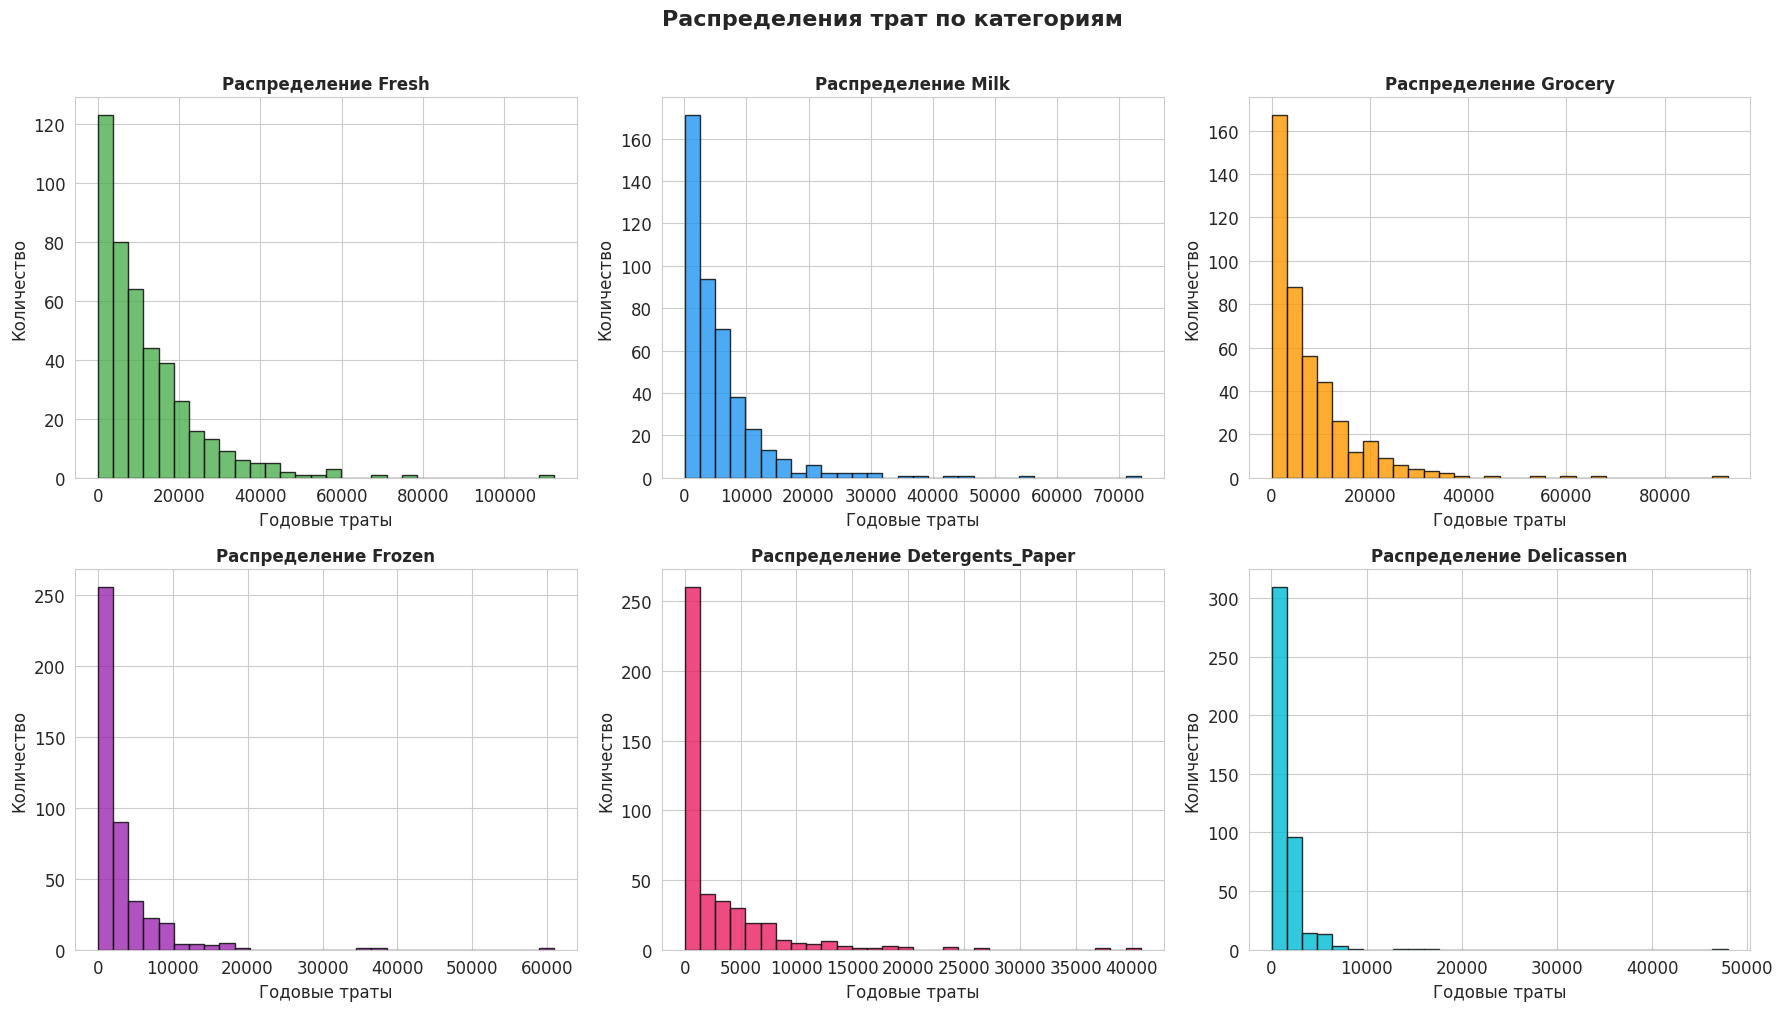

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
colors_hist = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#E91E63', '#00BCD4']

for idx, (col, color) in enumerate(zip(spend_cols, colors_hist)):
    axes[idx].hist(df[col], bins=30, color=color, edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Годовые траты')
    axes[idx].set_ylabel('Количество')

plt.suptitle('Распределения трат по категориям', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

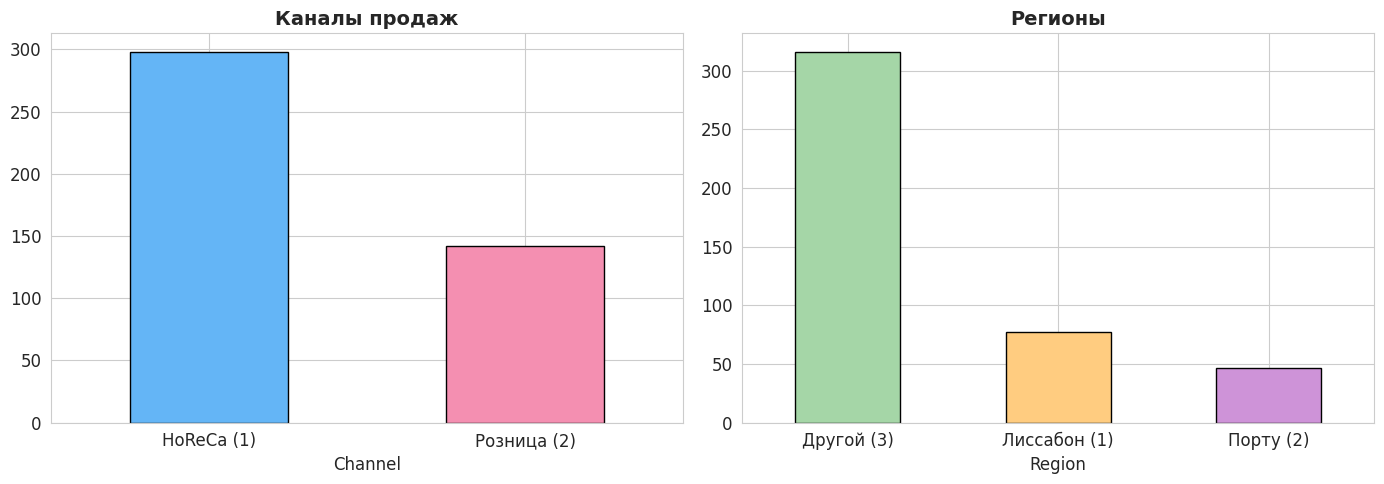

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Channel'].value_counts().plot(kind='bar', color=['#64B5F6', '#F48FB1'],
                                   edgecolor='black', ax=axes[0])
axes[0].set_title('Каналы продаж', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['HoReCa (1)', 'Розница (2)'], rotation=0)

df['Region'].value_counts().plot(kind='bar', color=['#A5D6A7', '#FFCC80', '#CE93D8'],
                                  edgecolor='black', ax=axes[1])
axes[1].set_title('Регионы', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Другой (3)', 'Лиссабон (1)', 'Порту (2)'], rotation=0)

plt.tight_layout()
plt.show()

## Предварительная обработка датасета

In [6]:
df_clean = df.copy()

# Используем только числовые признаки трат (без Channel и Region)
feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df_features = df_clean[feature_cols].copy()

print(f"Признаки для кластеризации: {feature_cols}")
print(f"Размер: {df_features.shape}")
print(f"Пропуски: {df_features.isnull().sum().sum()}")

# Удаление дубликатов
dupl = df_features.duplicated().sum()
print(f"Дубликаты: {dupl}")
if dupl > 0:
    df_features = df_features.drop_duplicates().reset_index(drop=True)
    print(f"После удаления: {df_features.shape}")

Признаки для кластеризации: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Размер: (440, 6)
Пропуски: 0
Дубликаты: 0


In [7]:
# Логарифмическое преобразование (траты имеют сильный правый скос)
df_log = np.log1p(df_features)

print("Логарифмическое преобразование (log1p) выполнено!")
print("\nСтатистика после log-преобразования:")
df_log.describe().round(2)

Логарифмическое преобразование (log1p) выполнено!

Статистика после log-преобразования:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,8.73,8.12,8.44,7.30,6.79,6.67
std,1.47,1.08,1.11,1.28,1.71,1.29
min,1.39,4.03,1.39,3.26,1.39,1.39
25%,8.05,7.34,7.68,6.61,5.55,6.01
50%,9.05,8.20,8.47,7.33,6.71,6.87
75%,9.74,8.88,9.27,8.18,8.27,7.51
max,11.63,11.21,11.44,11.02,10.62,10.78


In [8]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

print("Масштабирование выполнено (StandardScaler)!")

# PCA для визуализации
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA (2D): объяснённая дисперсия = {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Данные для кластеризации: {X_scaled.shape}")

Масштабирование выполнено (StandardScaler)!

PCA (2D): объяснённая дисперсия = 71.27%
Данные для кластеризации: (440, 6)


## Тепловая карта корреляций (Heatmap)

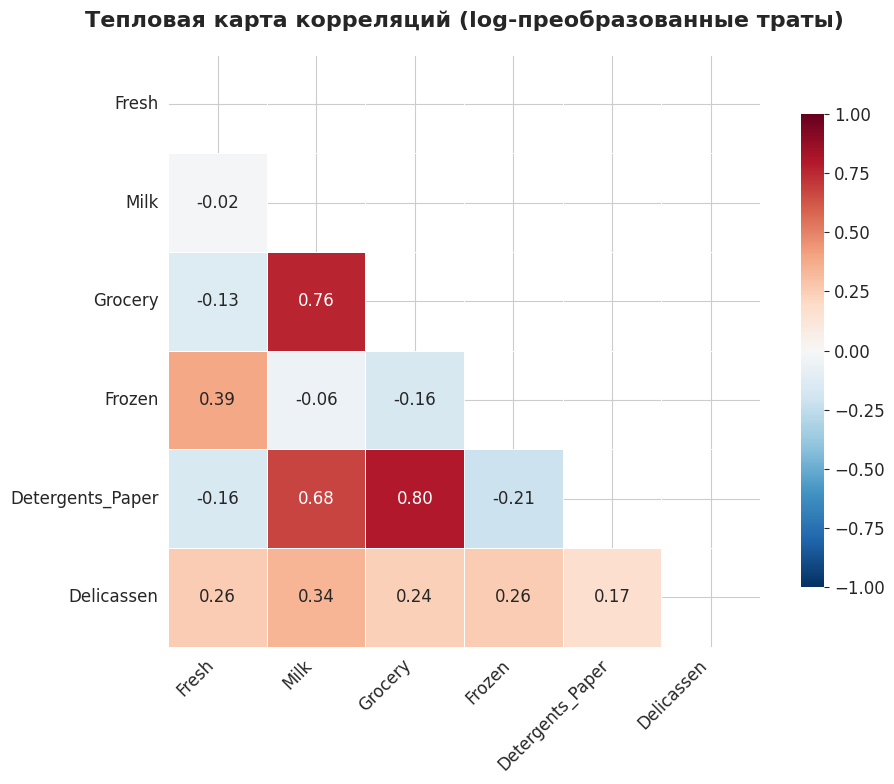

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

correlation_matrix = df_log.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Тепловая карта корреляций (log-преобразованные траты)',
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
corr_pairs = []
cols = correlation_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_pairs.append({
            'Признак 1': cols[i],
            'Признак 2': cols[j],
            'Корреляция': correlation_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs)
corr_pairs_df['|Корреляция|'] = corr_pairs_df['Корреляция'].abs()
corr_pairs_df = corr_pairs_df.sort_values('|Корреляция|', ascending=False).reset_index(drop=True)
corr_pairs_df.index += 1

print("=" * 70)
print("РЕЙТИНГ ПАР ПРИЗНАКОВ ПО СИЛЕ КОРРЕЛЯЦИИ")
print("=" * 70)
for _, row in corr_pairs_df.iterrows():
    strength = "сильная" if row['|Корреляция|'] >= 0.7 else "средняя" if row['|Корреляция|'] >= 0.4 else "слабая"
    direction = "+" if row['Корреляция'] > 0 else "-"
    print(f"  {row['Признак 1']:<18} <-> {row['Признак 2']:<18} r = {row['Корреляция']:+.4f} ({strength}, {direction})")

РЕЙТИНГ ПАР ПРИЗНАКОВ ПО СИЛЕ КОРРЕЛЯЦИИ
  Grocery            <-> Detergents_Paper   r = +0.7971 (сильная, +)
  Milk               <-> Grocery            r = +0.7611 (сильная, +)
  Milk               <-> Detergents_Paper   r = +0.6787 (средняя, +)
  Fresh              <-> Frozen             r = +0.3863 (слабая, +)
  Milk               <-> Delicassen         r = +0.3423 (слабая, +)
  Fresh              <-> Delicassen         r = +0.2564 (слабая, +)
  Frozen             <-> Delicassen         r = +0.2563 (слабая, +)
  Grocery            <-> Delicassen         r = +0.2400 (слабая, +)
  Frozen             <-> Detergents_Paper   r = -0.2128 (слабая, -)
  Detergents_Paper   <-> Delicassen         r = +0.1676 (слабая, +)
  Grocery            <-> Frozen             r = -0.1645 (слабая, -)
  Fresh              <-> Detergents_Paper   r = -0.1587 (слабая, -)
  Fresh              <-> Grocery            r = -0.1330 (слабая, -)
  Milk               <-> Frozen             r = -0.0552 (слабая, -)
  Fr

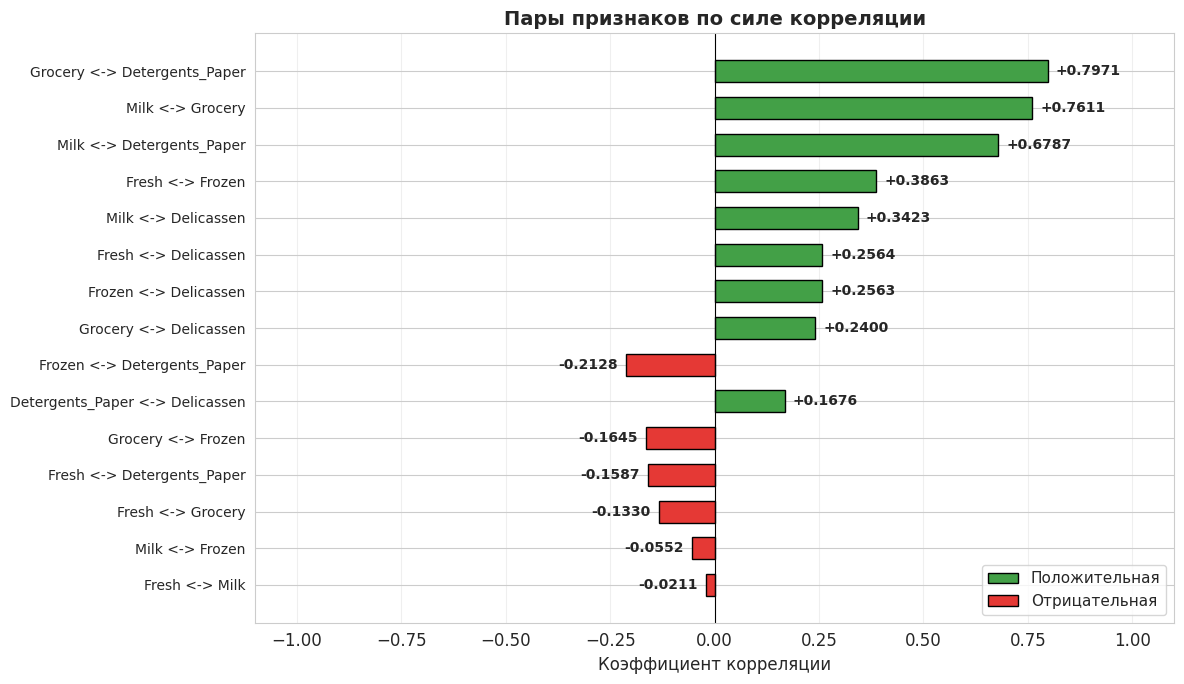

In [11]:
top_n = len(corr_pairs_df)
fig, ax = plt.subplots(figsize=(12, 7))

pair_labels = [f"{row['Признак 1']} <-> {row['Признак 2']}" for _, row in corr_pairs_df.iterrows()]
values = corr_pairs_df['Корреляция'].values
colors_bar = ['#E53935' if v < 0 else '#43A047' for v in values]

bars = ax.barh(range(top_n), values, color=colors_bar, edgecolor='black', height=0.6)
for i, (bar, v) in enumerate(zip(bars, values)):
    offset = 0.02 if v >= 0 else -0.02
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.4f}', va='center', ha=ha, fontweight='bold', fontsize=10)

ax.set_yticks(range(top_n))
ax.set_yticklabels(pair_labels, fontsize=10)
ax.set_xlabel('Коэффициент корреляции', fontsize=12)
ax.set_title('Пары признаков по силе корреляции', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlim(-1.1, 1.1)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

legend_elements = [Patch(facecolor='#43A047', edgecolor='black', label='Положительная'),
                   Patch(facecolor='#E53935', edgecolor='black', label='Отрицательная')]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

## Подбор гиперпараметров

In [52]:
# Автоматическая оценка bandwidth
auto_bw = estimate_bandwidth(X_scaled, quantile=0.3, random_state=42)
print(f"Автоматическая оценка bandwidth (quantile=0.3): {auto_bw:.3f}")

# Пробуем разные quantile
for q in [0.1, 0.2, 0.3, 0.4, 0.5]:
    bw = estimate_bandwidth(X_scaled, quantile=q, random_state=42)
    print(f"  quantile={q}: bandwidth={bw:.3f}")

# Формируем сетку bandwidth вокруг автоматической оценки
bw_min = max(0, auto_bw - 0.5)
bw_max = auto_bw + 0.5
bw_range = np.round(np.linspace(bw_min, bw_max, 10), 2).tolist()

print(f"\nДиапазон bandwidth для перебора: {bw_range}")

Автоматическая оценка bandwidth (quantile=0.3): 2.503
  quantile=0.1: bandwidth=1.828
  quantile=0.2: bandwidth=2.197
  quantile=0.3: bandwidth=2.503
  quantile=0.4: bandwidth=2.786
  quantile=0.5: bandwidth=3.063

Диапазон bandwidth для перебора: [2.0, 2.11, 2.23, 2.34, 2.45, 2.56, 2.67, 2.78, 2.89, 3.0]


In [53]:
param_grid = {
    'bandwidth': bw_range,
    'bin_seeding': [True],
    'cluster_all': [False]
}

all_params = list(ParameterGrid(param_grid))
cv = 3

print("=" * 60)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ MEANSHIFT (cv=3)")
print("=" * 60)
print(f"\nСетка параметров:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
print(f"\nВсего комбинаций: {len(all_params)}")
print(f"С учётом cv=3: {len(all_params) * 3} обучений")
print("\nПеребор начат...")

results = []

for idx, params in enumerate(all_params):
    sil_scores, ch_scores, db_scores = [], [], []
    n_clusters_list, orphan_pct_list, times_list = [], [], []

    for seed in range(cv):
        np.random.seed(seed * 42 + 7)
        sub_idx = np.random.choice(len(X_scaled), size=int(len(X_scaled) * 0.8), replace=False)
        X_sub = X_scaled[sub_idx]

        try:
            t0 = time.time()
            model = MeanShift(
                bandwidth=params['bandwidth'],
                bin_seeding=params['bin_seeding'],
                cluster_all=params['cluster_all'],
                n_jobs=-1
            )
            labels = model.fit_predict(X_sub)
            elapsed = time.time() - t0

            n_clusters = len(np.unique(labels))
            orphan_pct = 0.0
            if not params['cluster_all']:
                orphan_pct = (labels == -1).sum() / len(labels) * 100

            n_clusters_list.append(n_clusters)
            orphan_pct_list.append(orphan_pct)
            times_list.append(elapsed)

            # Метрики
            valid_mask = labels != -1
            n_unique = len(np.unique(labels[valid_mask])) if valid_mask.sum() > 0 else 0
            if n_unique >= 2:
                sil_scores.append(silhouette_score(X_sub[valid_mask], labels[valid_mask]))
                ch_scores.append(calinski_harabasz_score(X_sub[valid_mask], labels[valid_mask]))
                db_scores.append(davies_bouldin_score(X_sub[valid_mask], labels[valid_mask]))

        except Exception:
            times_list.append(np.nan)
            continue

    results.append({
        'params': params,
        'bandwidth': params['bandwidth'],
        'bin_seeding': params['bin_seeding'],
        'cluster_all': params['cluster_all'],
        'mean_n_clusters': np.mean(n_clusters_list) if n_clusters_list else 0,
        'mean_orphan_pct': np.mean(orphan_pct_list) if orphan_pct_list else 0,
        'mean_silhouette': np.mean(sil_scores) if sil_scores else np.nan,
        'std_silhouette': np.std(sil_scores) if sil_scores else np.nan,
        'mean_calinski_harabasz': np.mean(ch_scores) if ch_scores else np.nan,
        'mean_davies_bouldin': np.mean(db_scores) if db_scores else np.nan,
        'mean_time': np.nanmean(times_list) if times_list else np.nan
    })

    if (idx + 1) % 10 == 0:
        print(f"  Обработано {idx + 1}/{len(all_params)}...")

results_df = pd.DataFrame(results)

# Фильтрация: >= 2 кластеров, не все в одном
results_df = results_df[results_df['mean_n_clusters'] >= 2].copy()
results_df = results_df.sort_values('mean_silhouette', ascending=False, na_position='last').reset_index(drop=True)
results_df.index += 1

print(f"\nПеребор завершён! Комбинаций после фильтрации (>=2 кластеров): {len(results_df)}")

ПОДБОР ГИПЕРПАРАМЕТРОВ MEANSHIFT (cv=3)

Сетка параметров:
  bandwidth: [2.0, 2.11, 2.23, 2.34, 2.45, 2.56, 2.67, 2.78, 2.89, 3.0]
  bin_seeding: [True]
  cluster_all: [False]

Всего комбинаций: 10
С учётом cv=3: 30 обучений

Перебор начат...
  Обработано 10/10...

Перебор завершён! Комбинаций после фильтрации (>=2 кластеров): 10


In [54]:
best_row = results_df.iloc[0]

print("=" * 70)
print("ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ")
print("=" * 70)
print(f"\n  bandwidth:    {best_row['bandwidth']}")
print(f"  bin_seeding:  {best_row['bin_seeding']}")
print(f"  cluster_all:  {best_row['cluster_all']}")
print(f"\n  Silhouette:        {best_row['mean_silhouette']:.4f} +/- {best_row['std_silhouette']:.4f}")
print(f"  Calinski-Harabasz: {best_row['mean_calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin:    {best_row['mean_davies_bouldin']:.4f}")
print(f"  Кластеров:         {best_row['mean_n_clusters']:.0f}")
print(f"  Время:             {best_row['mean_time']:.4f} сек")

ЛУЧШАЯ КОМБИНАЦИЯ ПАРАМЕТРОВ

  bandwidth:    2.89
  bin_seeding:  True
  cluster_all:  False

  Silhouette:        0.6105 +/- 0.0166
  Calinski-Harabasz: 13.64
  Davies-Bouldin:    0.2654
  Кластеров:         4
  Время:             0.1885 сек


In [55]:
print("=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: bandwidth")
print("=" * 70)
bw_s = results_df.groupby('bandwidth').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_orphan_pct': 'mean',
    'mean_time': 'mean'
}).round(4)
bw_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Сироты % (ср)', 'Время (ср)']
print(bw_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: bin_seeding")
print("=" * 70)
bs_s = results_df.groupby('bin_seeding').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_time': 'mean'
}).round(4)
bs_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Время (ср)']
print(bs_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: cluster_all")
print("=" * 70)
ca_s = results_df.groupby('cluster_all').agg({
    'mean_silhouette': ['mean', 'max'],
    'mean_n_clusters': 'mean',
    'mean_orphan_pct': 'mean'
}).round(4)
ca_s.columns = ['Sil (ср)', 'Sil (макс)', 'Кластеров (ср)', 'Сироты % (ср)']
print(ca_s)

ВЛИЯНИЕ ПАРАМЕТРА: bandwidth
           Sil (ср)  Sil (макс)  Кластеров (ср)  Сироты % (ср)  Время (ср)
bandwidth                                                                 
2.00         0.4585      0.4585         11.0000        46.0227      0.5182
2.11         0.4664      0.4664         11.0000        41.9508      0.4361
2.23         0.4937      0.4937          9.0000        37.6894      0.3858
2.34         0.5226      0.5226          7.0000        33.5227      0.2848
2.45         0.5656      0.5656          5.3333        32.0076      0.2220
2.56         0.5455      0.5455          5.0000        29.1667      0.1874
2.67         0.5495      0.5495          5.3333        26.2311      0.1576
2.78         0.5780      0.5780          4.6667        22.7273      0.1587
2.89         0.6105      0.6105          4.3333        19.4129      0.1885
3.00         0.6006      0.6006          4.3333        16.1932      0.1544

ВЛИЯНИЕ ПАРАМЕТРА: bin_seeding
             Sil (ср)  Sil (макс)  Клас

## Обучение модели

In [56]:
best_params = results_df.iloc[0]['params']

print("=" * 60)
print("ОБУЧЕНИЕ ЛУЧШЕЙ МОДЕЛИ MEANSHIFT")
print("=" * 60)
print(f"\n  bandwidth:    {best_params['bandwidth']}")
print(f"  bin_seeding:  {best_params['bin_seeding']}")
print(f"  cluster_all:  {best_params['cluster_all']}")

t0 = time.time()
best_model = MeanShift(
    bandwidth=best_params['bandwidth'],
    bin_seeding=best_params['bin_seeding'],
    cluster_all=best_params['cluster_all'],
    n_jobs=-1
)
best_labels = best_model.fit_predict(X_scaled)
elapsed = time.time() - t0

n_clusters = len(np.unique(best_labels[best_labels != -1]))
n_orphan = (best_labels == -1).sum()

print(f"\n  Время: {elapsed:.4f} сек")
print(f"  Кластеров: {n_clusters}")
print(f"  Неприсвоенных (cluster_all=False): {n_orphan}")
print(f"  Центроидов: {len(best_model.cluster_centers_)}")

print(f"\nРаспределение:")
unique, counts = np.unique(best_labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    name = "Неприсвоенные" if cl == -1 else f"Кластер {cl}"
    print(f"  {name}: {cnt} ({cnt/len(best_labels)*100:.1f}%)")

ОБУЧЕНИЕ ЛУЧШЕЙ МОДЕЛИ MEANSHIFT

  bandwidth:    2.89
  bin_seeding:  True
  cluster_all:  False

  Время: 0.1824 сек
  Кластеров: 4
  Неприсвоенных (cluster_all=False): 90
  Центроидов: 4

Распределение:
  Неприсвоенные: 90 (20.5%)
  Кластер 0: 347 (78.9%)
  Кластер 1: 1 (0.2%)
  Кластер 2: 1 (0.2%)
  Кластер 3: 1 (0.2%)


In [57]:
df_result = df_features.copy()
df_result['Cluster'] = best_labels

print("=" * 60)
print("ПРОФИЛИ КЛАСТЕРОВ (средние значения трат)")
print("=" * 60)

profile = df_result.groupby('Cluster')[feature_cols].mean().round(0)
profile['Количество'] = df_result.groupby('Cluster').size()
profile['Доля (%)'] = (profile['Количество'] / len(df_result) * 100).round(1)
profile

ПРОФИЛИ КЛАСТЕРОВ (средние значения трат)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Количество,Доля (%)
Cluster,,,,,,,,
-1,9701.0,10155.0,15102.0,3230.0,6417.0,2150.0,90,20.5
0,12640.0,4711.0,6145.0,3000.0,1989.0,1371.0,347,78.9
1,20398.0,1137.0,3.0,4407.0,3.0,975.0,1,0.2
2,622.0,55.0,137.0,75.0,7.0,8.0,1,0.2
3,3.0,333.0,7021.0,15601.0,15.0,550.0,1,0.2


In [58]:
# Добавляем Channel и Region для анализа
df_result['Channel'] = df_clean['Channel'].values[:len(df_result)]
df_result['Region'] = df_clean['Region'].values[:len(df_result)]

print("=" * 60)
print("КАНАЛЫ И РЕГИОНЫ ПО КЛАСТЕРАМ")
print("=" * 60)

for cl in sorted(df_result['Cluster'].unique()):
    if cl == -1:
        continue
    subset = df_result[df_result['Cluster'] == cl]
    print(f"\n  Кластер {cl} ({len(subset)} клиентов):")
    ch_dist = subset['Channel'].value_counts()
    for ch, cnt in ch_dist.items():
        ch_name = "HoReCa" if ch == 1 else "Розница"
        print(f"    {ch_name}: {cnt} ({cnt/len(subset)*100:.0f}%)")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 15 КЛИЕНТОВ")
print("=" * 60)
df_result.head(15)

КАНАЛЫ И РЕГИОНЫ ПО КЛАСТЕРАМ

  Кластер 0 (347 клиентов):
    HoReCa: 249 (72%)
    Розница: 98 (28%)

  Кластер 1 (1 клиентов):
    HoReCa: 1 (100%)

  Кластер 2 (1 клиентов):
    HoReCa: 1 (100%)

  Кластер 3 (1 клиентов):
    HoReCa: 1 (100%)

ПЕРВЫЕ 15 КЛИЕНТОВ


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Channel,Region
0,12669,9656,7561,214,2674,1338,0,2,3
1,7057,9810,9568,1762,3293,1776,0,2,3
2,6353,8808,7684,2405,3516,7844,0,2,3
3,13265,1196,4221,6404,507,1788,0,1,3
4,22615,5410,7198,3915,1777,5185,0,2,3
5,9413,8259,5126,666,1795,1451,0,2,3
6,12126,3199,6975,480,3140,545,0,2,3
7,7579,4956,9426,1669,3321,2566,0,2,3
8,5963,3648,6192,425,1716,750,0,1,3
9,6006,11093,18881,1159,7425,2098,0,2,3


## Графики выходных результатов

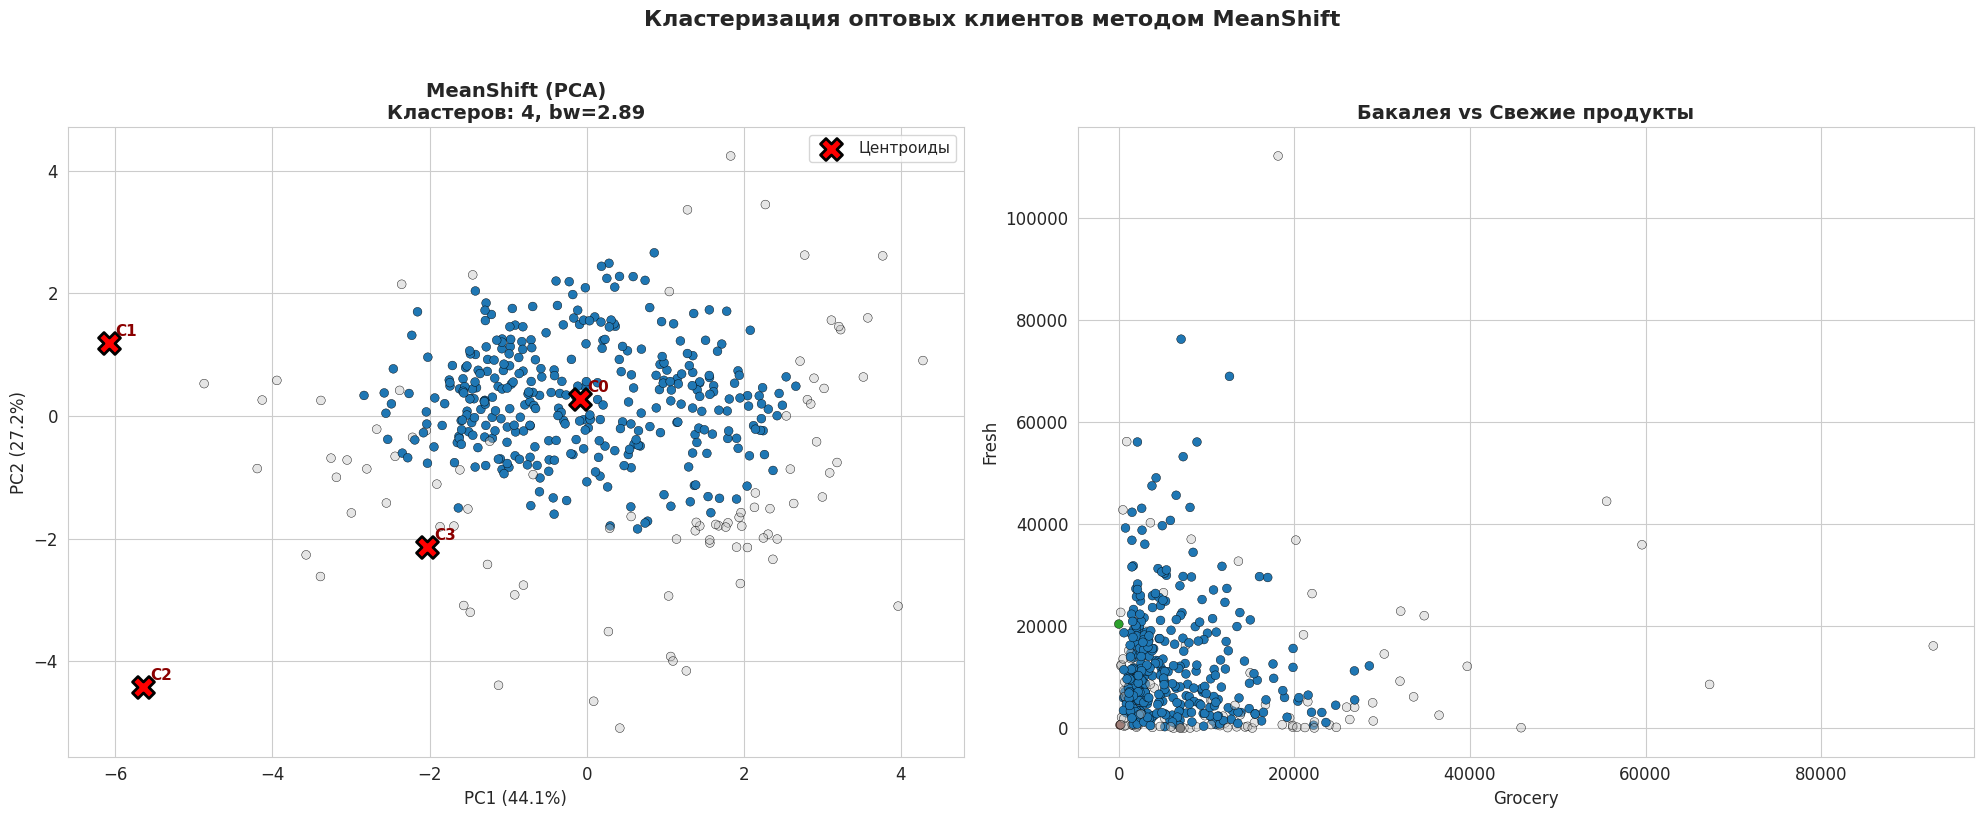

In [59]:
centroids_pca = pca.transform(best_model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA
unique_l = sorted(set(best_labels))
cmap_vis = plt.cm.tab10
cm_vis = {}
ci = 0
for lbl in unique_l:
    if lbl == -1:
        cm_vis[lbl] = (0.75, 0.75, 0.75, 0.4)
    else:
        cm_vis[lbl] = cmap_vis(ci / max(n_clusters, 1))
        ci += 1
point_colors = [cm_vis[l] for l in best_labels]

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, s=40, edgecolors='black', linewidths=0.3)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red',
                marker='X', s=250, edgecolors='black', linewidths=2, zorder=5, label='Центроиды')
for c_idx in range(len(centroids_pca)):
    axes[0].annotate(f'C{c_idx}', xy=(centroids_pca[c_idx, 0], centroids_pca[c_idx, 1]),
                     fontsize=11, fontweight='bold', color='darkred',
                     xytext=(5, 5), textcoords='offset points')
axes[0].set_title(f'MeanShift (PCA)\nКластеров: {n_clusters}, bw={best_params["bandwidth"]}',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=11)

# Grocery vs Fresh
axes[1].scatter(df_result['Grocery'], df_result['Fresh'],
                c=point_colors, s=40, edgecolors='black', linewidths=0.3)
axes[1].set_title('Бакалея vs Свежие продукты', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grocery')
axes[1].set_ylabel('Fresh')

plt.suptitle('Кластеризация оптовых клиентов методом MeanShift',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [60]:
valid_mask = best_labels != -1
labels_valid = best_labels[valid_mask]

print("=" * 60)
print("МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("=" * 60)

if len(np.unique(labels_valid)) >= 2:
    sil = silhouette_score(X_scaled[valid_mask], labels_valid)
    ch = calinski_harabasz_score(X_scaled[valid_mask], labels_valid)
    db = davies_bouldin_score(X_scaled[valid_mask], labels_valid)
    print(f"\n  Silhouette Score:        {sil:.4f}")
    print(f"  Calinski-Harabasz Index: {ch:.2f}")
    print(f"  Davies-Bouldin Index:    {db:.4f}")
else:
    sil, ch, db = np.nan, np.nan, np.nan
    print("\n  Недостаточно кластеров для метрик")

print(f"\n  Кластеров: {n_clusters}")
print(f"  Центроидов: {len(best_model.cluster_centers_)}")

МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ

  Silhouette Score:        0.5969
  Calinski-Harabasz Index: 13.39
  Davies-Bouldin Index:    0.2696

  Кластеров: 4
  Центроидов: 4


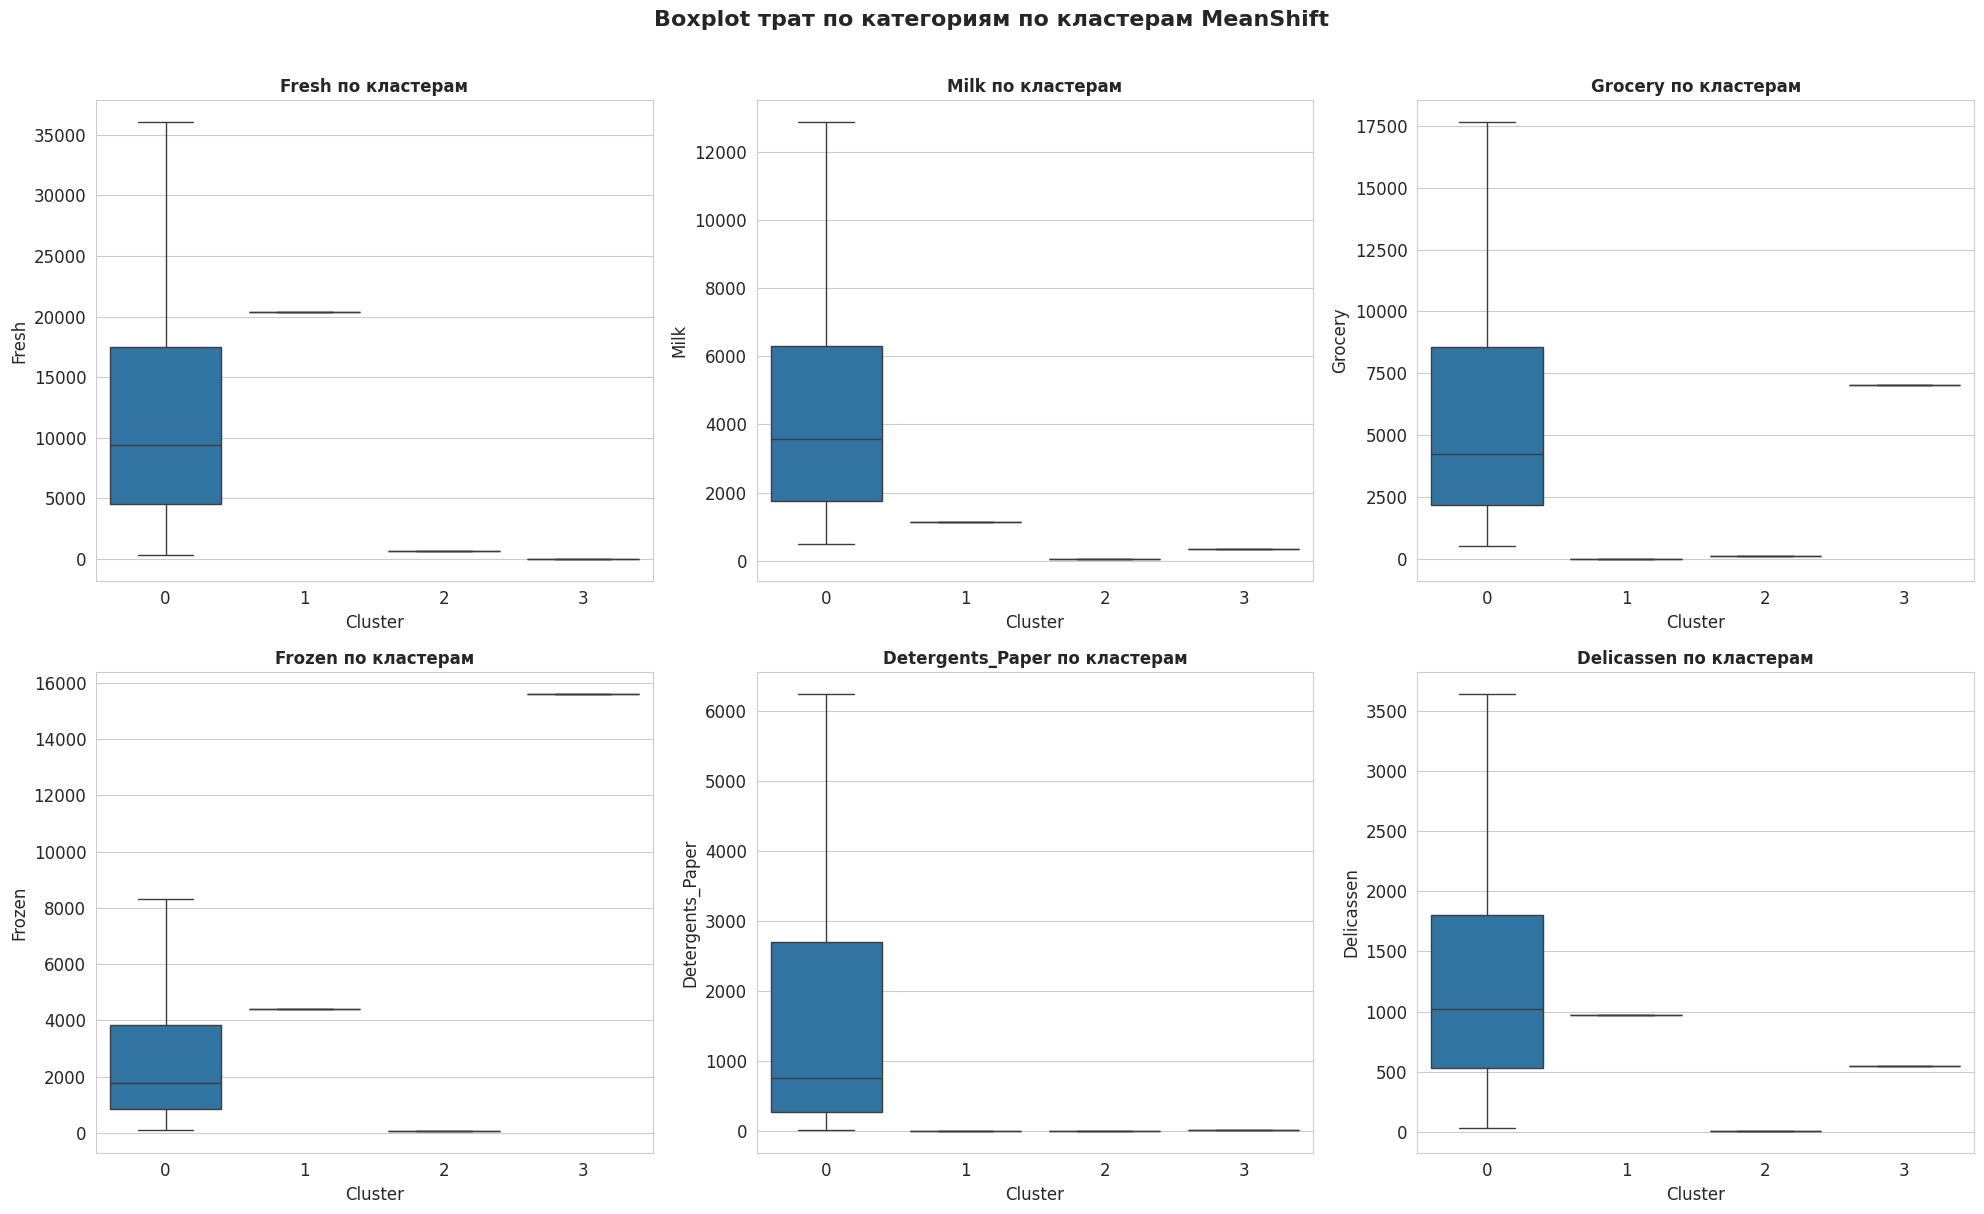

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

df_plot = df_result[df_result['Cluster'] != -1].copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)

for idx, feat in enumerate(feature_cols):
    sns.boxplot(data=df_plot, x='Cluster', y=feat, ax=axes[idx],
                palette='tab10', showfliers=False)
    axes[idx].set_title(f'{feat} по кластерам', fontsize=12, fontweight='bold')

plt.suptitle('Boxplot трат по категориям по кластерам MeanShift',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

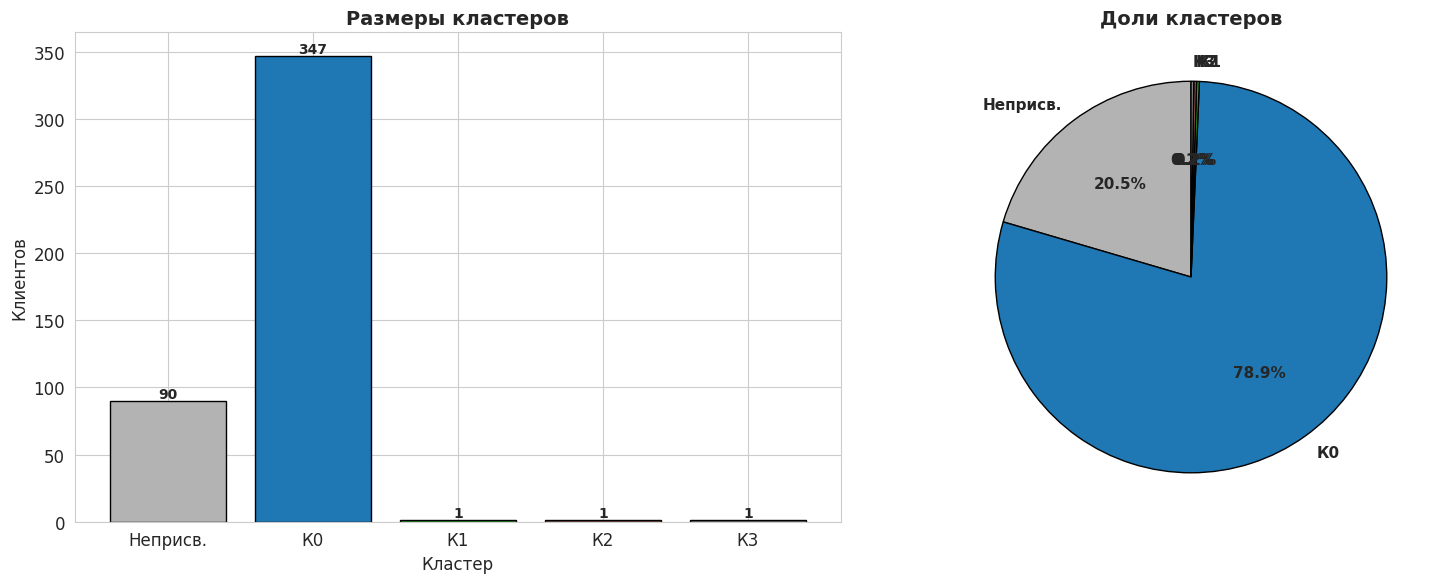

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Размеры
cluster_counts = pd.Series(best_labels).value_counts().sort_index()
cl_names = ['Неприсв.' if c == -1 else f'К{c}' for c in cluster_counts.index]
cl_colors = [(0.7, 0.7, 0.7) if c == -1 else plt.cm.tab10(c / max(n_clusters, 1))
             for c in cluster_counts.index]

bars = axes[0].bar(cl_names, cluster_counts.values, color=cl_colors, edgecolor='black')
for bar, val in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Размеры кластеров', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('Клиентов')

# Круговая
axes[1].pie(cluster_counts.values, labels=cl_names, colors=cl_colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Доли кластеров', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Интерпретация кластеров

In [63]:
print("=" * 70)
print("ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ")
print("=" * 70)

global_means = df_features[feature_cols].mean()

segment_names = {}
segment_descriptions = {}
segment_recommendations = {}

for cl in sorted(df_result['Cluster'].unique()):
    subset = df_result[df_result['Cluster'] == cl]
    count = len(subset)

    if cl == -1:
        segment_names[-1] = "Нераспределённые"
        segment_descriptions[-1] = "не вписались ни в один кластер плотности"
        segment_recommendations[-1] = "индивидуальный анализ, возможные нетипичные клиенты"
        continue

    cl_means = subset[feature_cols].mean()
    name_parts, desc_parts, rec_parts = [], [], []

    # Fresh
    if cl_means['Fresh'] > global_means['Fresh'] * 1.5:
        name_parts.append("Любители свежего")
        desc_parts.append("очень высокие траты на свежие продукты")
        rec_parts.append("приоритетная доставка свежих продуктов, скидки на объём")
    elif cl_means['Fresh'] < global_means['Fresh'] * 0.5:
        desc_parts.append("низкие траты на свежие продукты")

    # Grocery + Detergents_Paper (розничный профиль)
    if cl_means['Grocery'] > global_means['Grocery'] * 1.5 and \
       cl_means['Detergents_Paper'] > global_means['Detergents_Paper'] * 1.5:
        name_parts.append("Розничные закупщики")
        desc_parts.append("высокие траты на бакалею и бытовую химию")
        rec_parts.append("пакетные предложения бакалея+химия, программа лояльности")

    # Milk
    if cl_means['Milk'] > global_means['Milk'] * 1.5:
        desc_parts.append("высокие траты на молочную продукцию")
        rec_parts.append("расширение молочного ассортимента")

    # Frozen
    if cl_means['Frozen'] > global_means['Frozen'] * 1.5:
        desc_parts.append("высокие траты на заморозку")
        rec_parts.append("специальные условия хранения и доставки заморозки")

    # Delicassen
    if cl_means['Delicassen'] > global_means['Delicassen'] * 1.5:
        name_parts.append("Премиум")
        desc_parts.append("высокие траты на деликатесы")
        rec_parts.append("эксклюзивные предложения, премиальный сервис")

    # Общий объём
    total_spend = cl_means[feature_cols].sum()
    global_total = global_means.sum()
    if total_spend > global_total * 1.5:
        if "Премиум" not in name_parts:
            name_parts.append("Крупные")
        desc_parts.append(f"общие траты в {total_spend/global_total:.1f}x выше среднего")
        rec_parts.append("персональный менеджер, приоритетное обслуживание")
    elif total_spend < global_total * 0.5:
        name_parts.append("Мелкие")
        desc_parts.append("общие траты значительно ниже среднего")
        rec_parts.append("стимулирование роста заказов, минимальные пороги для скидок")

    # Channel доминанта
    if 'Channel' in subset.columns:
        horeca_pct = (subset['Channel'] == 1).sum() / count * 100
        if horeca_pct > 70:
            desc_parts.append(f"преимущественно HoReCa ({horeca_pct:.0f}%)")
        elif horeca_pct < 30:
            desc_parts.append(f"преимущественно розница ({100-horeca_pct:.0f}%)")

    if not name_parts:
        name_parts.append("Типичные")
    if not rec_parts:
        rec_parts.append("стандартные условия обслуживания")

    segment_names[cl] = " / ".join(name_parts)
    segment_descriptions[cl] = "; ".join(desc_parts) if desc_parts else "средние показатели"
    segment_recommendations[cl] = "; ".join(rec_parts)

# Вывод
for cl in sorted(segment_names.keys()):
    subset = df_result[df_result['Cluster'] == cl]
    count = len(subset)
    pct = count / len(df_result) * 100
    cl_label = "НЕПРИСВ." if cl == -1 else f"КЛАСТЕР {cl}"

    print(f"\n{'━' * 70}")
    print(f"  {cl_label}: «{segment_names[cl]}»")
    print(f"  {count} клиентов ({pct:.1f}%)")
    print(f"{'━' * 70}")
    print(f"  📋 Характеристика: {segment_descriptions[cl]}")
    print(f"  🎯 Рекомендации:   {segment_recommendations[cl]}")

    if cl != -1:
        cl_means = subset[feature_cols].mean()
        top_cat = cl_means.idxmax()
        print(f"  📊 Топ-категория: {top_cat} ({cl_means[top_cat]:,.0f})")
        print(f"  📊 Общие траты: {cl_means.sum():,.0f} (среднее по клиенту)")

ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  НЕПРИСВ.: «Нераспределённые»
  90 клиентов (20.5%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: не вписались ни в один кластер плотности
  🎯 Рекомендации:   индивидуальный анализ, возможные нетипичные клиенты

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  КЛАСТЕР 0: «Типичные»
  347 клиентов (78.9%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: преимущественно HoReCa (72%)
  🎯 Рекомендации:   стандартные условия обслуживания
  📊 Топ-категория: Fresh (12,640)
  📊 Общие траты: 29,856 (среднее по клиенту)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  КЛАСТЕР 1: «Любители свежего»
  1 клиентов (0.2%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋 Характеристика: очень высокие траты на свежие продукты; преимущественно HoReC

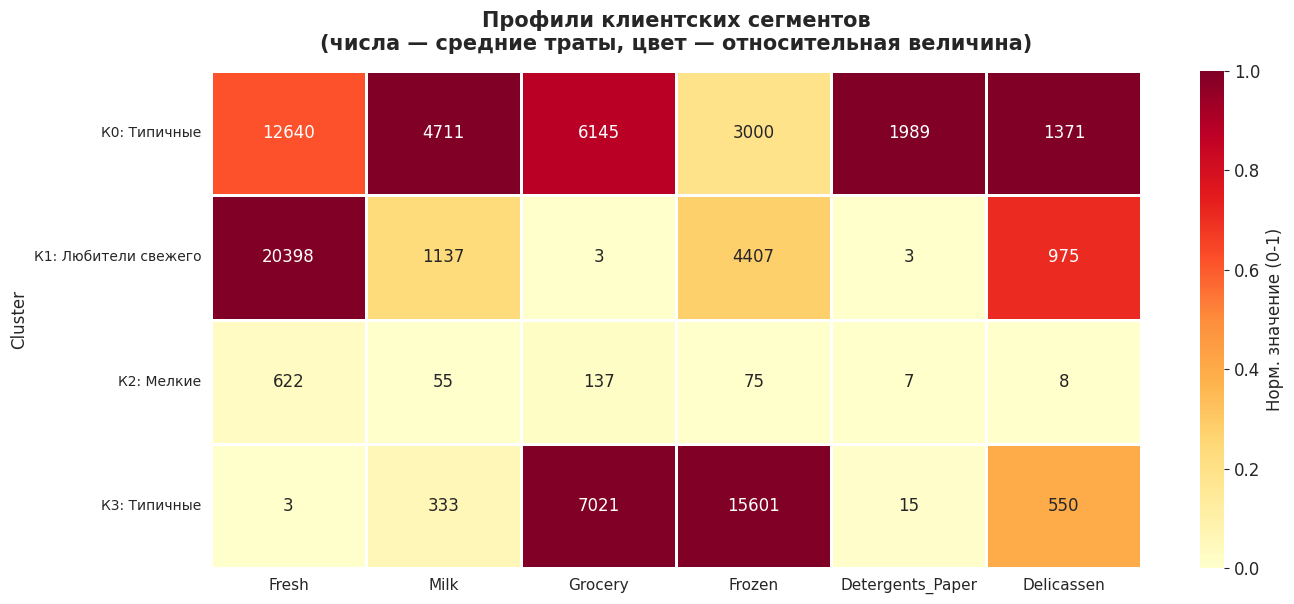

In [64]:
# Тепловая карта профилей
cluster_ids = sorted([cl for cl in segment_names.keys() if cl != -1])

if len(cluster_ids) > 0:
    profile_cl = profile.loc[cluster_ids, feature_cols]
    profile_norm = (profile_cl - profile_cl.min()) / (profile_cl.max() - profile_cl.min() + 1e-10)
    row_labels = [f'К{cl}: {segment_names[cl]}' for cl in cluster_ids]

    fig, ax = plt.subplots(figsize=(14, max(len(cluster_ids) * 1.3 + 1, 4)))
    sns.heatmap(profile_norm, annot=profile_cl.values, fmt='.0f', cmap='YlOrRd',
                xticklabels=feature_cols, yticklabels=row_labels,
                linewidths=1, cbar_kws={'label': 'Норм. значение (0-1)'}, ax=ax)
    ax.set_title('Профили клиентских сегментов\n(числа — средние траты, цвет — относительная величина)',
                 fontsize=15, fontweight='bold', pad=15)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()